## Selection on Observables:


10 — Matching <br>
11 — Propensity Score <br>
12 — Doubly Robust Estimation

In [7]:
import pandas as pd
import numpy as np
from scipy.special import expit
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import style
import statsmodels.formula.api as smf
import graphviz as gr
from sklearn.linear_model import LogisticRegression, LinearRegression

%matplotlib inline

style.use("fivethirtyeight")
pd.set_option("display.max_columns", 6)

from causalinference import CausalModel


import os
os.getcwd()
os.chdir('/Users/hiro/Documents/github/Causal_Inference/')

Chapter 10

6 men, 4 women. Y = days hospitalised. T = drug. On men, $\beta_{Y \sim T} = -3$, on women, $\beta_{Y \sim T} = -2$. Men are more affected by the illness and stay longer at the hospital and get more of the drug. 1/6 do not get the drug. Women are more resistant to the illness and stay less at the hospital. 50% of the women get the drug.


In [22]:
drug_example = pd.DataFrame(dict(
    sex= ["M","M","M","M","M","M", "W","W","W","W"],
    drug=[1,1,1,1,1,0,  1,0,1,0],
    days=[5,5,5,5,5,8,  2,4,2,4]
))
drug_example.query("drug==1")["days"].mean() - drug_example.query("drug==0")["days"].mean()


np.float64(-1.1904761904761898)

In [ ]:
ATE SHOULD BE = -2.6

This estimate is done by
1. partitioning the data into confounder cells, in this case, men and women
2. estimating the effect on each cell
3.  combining the estimate with a weighted average, where the weight is the sample size of the cell or covariate group.

If we had exactly the same number of men and women in the data, the ATE estimate would be right in the middle of the ATE of the 2 groups, -2.5. Since there are more men than women in our dataset, the ATE estimate is a little bit closer to the men’s ATE. This is called a non-parametric estimate, since it places no assumption on how the data was generated.

If we control for sex using regression, we will add the assumption of linearity. Regression will also partition the data into men and women and estimate the effect on both of these groups. 

However, when it comes to combining the effect on each group, it does not weigh them just by the sample size. Instead, regression uses weights that are also proportional to the variance of the treatment in that group. In our case, the variance of the treatment in men is smaller than in women, since only one man is in the control group. To be exact, the variance of T for men is $0.139 = 1/6 \times (1 - 1/6)$ and for women is $0.25 = 2/4 * (1- 2/4) $. So regression will give a higher weight to women in our example and the ATE will be a bit closer to the women’s ATE of -2.

In [23]:
smf.ols('days ~ drug + C(sex)', data=drug_example).fit().summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,7.5455,0.188,40.093,0.000,7.100,7.990
C(sex)[T.W],-3.3182,0.176,-18.849,0.000,-3.734,-2.902
drug,-2.4545,0.188,-13.042,0.000,-2.900,-2.010


So we’ve seen that regression has its idiosyncrasies. It is linear, parametric, likes high variance features… This can be good or bad, depending on the context. Because of this, it’s important to be aware of other techniques we can use to control for confounders. Not only are they an extra tool in your causal tool belt, but understanding different ways to deal with confounding expands our understanding of the problem. For this reason, I present you now the Subclassification Estimator!

We need to estimate the effect of the training program within small groups of individuals that are roughly the same in motivation level and any other confounders we may have -> looking for confounders. Need to compare treatment VS control where $X$ is the same. 

If conditional independence, then $(Y_{0}, Y_1) \perp T|X$, then 

$$ATE = \int (E[Y|X, T = 1] - E[Y|X, T = 0])dP(x)$$
$$\hat{ATE} = \sum_{k = 1}^n (\bar{Y}_{k1} - \bar{Y}_{k0}) \frac{N_k}{N}$$

MATCHING ESTIMATOR

Since some sort of confounder $X$ makes it so that treated and untreated are not initially comparable, I can make them so by matching each treated unit with a similar untreated unit



In [26]:
trainee = pd.read_csv("./data/trainees.csv")
print(trainee.query("trainees==1"))
print(trainee.query("trainees==0"))

    unit  trainees  age  earnings
0      1         1   28     17700
1      2         1   34     10200
2      3         1   29     14400
3      4         1   25     20800
4      5         1   29      6100
5      6         1   23     28600
6      7         1   33     21900
7      8         1   27     28800
8      9         1   31     20300
9     10         1   26     28100
10    11         1   25      9400
11    12         1   27     14300
12    13         1   29     12500
13    14         1   24     19700
14    15         1   25     10100
15    16         1   43     10700
16    17         1   28     11500
17    18         1   27     10700
18    19         1   28     16300
    unit  trainees  age  earnings
19    20         0   43     20900
20    21         0   50     31000
21    22         0   30     21000
22    23         0   27      9300
23    24         0   54     41100
24    25         0   48     29800
25    26         0   39     42000
26    27         0   28      8800
27    28      

In [28]:
print(trainee.query("trainees==1")["earnings"].mean() - trainee.query("trainees==0")["earnings"].mean()) #-4297.49373433584
#Trainees receive much less but age is confounder

# make dataset where no one has the same age
unique_on_age = (trainee
                 .query("trainees==0")
                 .drop_duplicates("age"))

matches = (trainee
           .query("trainees==1")
           .merge(unique_on_age, on="age", how="left", suffixes=("_t_1", "_t_0"))
           .assign(t1_minuts_t0 = lambda d: d["earnings_t_1"] - d["earnings_t_0"]))

matches.head(7)

matches["t1_minuts_t0"].mean() #2457.8947368421054

-4297.49373433584


np.float64(2457.8947368421054)

$$\hat{ATE} = \frac{\sum_{i=1}^N (2T_i-1)(Y_i-Y_{jm}(i))}{N}$$

where $Y_{jm}(i) = $ sample of the other group most similar to $Y_i$. So $()$ is 1 if treated and -1 if untreated 

In [31]:
med = pd.read_csv("./data/medicine_impact_recovery.csv")
med.head()

np.float64(16.895799546498726)

In [35]:
med.query("medication==1")["recovery"].mean() - med.query("medication==0")["recovery"].mean() #Diff of means = 16.9 days to recover the treated. Strange

#CORRECT FOR BIAS
# scale features
X = ["severity", "age", "sex"]
y = "recovery"

med = med.assign(**{f: (med[f] - med[f].mean())/med[f].std() for f in X}) #STANDARDISE
med.head()

#Now, to the matching itself. We will use the K nearest neighbour algorithm from Sklearn. 

,sex,age,severity,medication,recovery
0,-0.996980,0.280787,1.459800,1,31
1,1.002979,0.865375,1.502164,1,49
2,1.002979,-0.338749,0.057796,0,38
3,1.002979,0.399465,-0.512557,0,35
4,-0.996980,-0.610473,-0.911125,0,15


For matching, we will need 2 of those. One, $mt0$, will store the untreated points and will find matches in the untreated when asked to do so. The other, $mt1$, will store the treated point and will find matches in the treated when asked to do so. After this fitting step, we can use these KNN models to make predictions, which will be our matches.

In [33]:
from sklearn.neighbors import KNeighborsRegressor

treated = med.query("medication==1")
untreated = med.query("medication==0")

mt0 = KNeighborsRegressor(n_neighbors=1).fit(untreated[X], untreated[y])
mt1 = KNeighborsRegressor(n_neighbors=1).fit(treated[X], treated[y])

predicted = pd.concat([
    # find matches for the treated looking at the untreated knn model
    treated.assign(match=mt0.predict(treated[X])),
    
    # find matches for the untreated looking at the treated knn model
    untreated.assign(match=mt1.predict(untreated[X]))
])

predicted.head()

,sex,age,...,recovery,match
0,-0.996980,0.280787,...,31,39.0
1,1.002979,0.865375,...,49,52.0
7,-0.996980,1.495134,...,38,46.0
10,1.002979,-0.106534,...,34,45.0
16,-0.996980,0.043034,...,30,39.0


In [36]:
np.mean((2*predicted["medication"] - 1)*(predicted["recovery"] - predicted["match"]))

np.float64(-0.9954)

Using matching, it goes from $+17$ days to $-1$ day. Can do better

$$\hat{ATET} = \frac{\sum Y_i - Y_j(i)}{N_1}$$
Where $N_1 = \#$ treated individuals and $Y_j(i) = $untreated match of treated $i$.

$\mu_0(x) = E[Y|X=x, T = 0]$ mean outcome for untreated given $X$. Counterfactual for an unit with $X = x$.
$$E[\sqrt{N_1}(\hat{ATET} - ATET)] = E[\sqrt{N_1}(\mu_0(X_i) - \mu_0(X_j(i)))]$$

Difference between $\hat{ATET} - ATET$ slowly converge to 0 but $N_1$ increases so it may not be 0.

Bias arises when the matching discrepancies are huge. Fortunately, we know how to correct it. Each observation contributes $(\mu_0(X_i) - \mu_0(X_j(i)))$ to the bias so all we need to do is subtract this quantity from each matching comparison in our estimator. To do so, we can replace $\mu_0(X_j(i))$  with some sort of estimate of this quantity $\hat{\mu}_0(X_j(i))$
, which can be obtained with models like linear regression. This updates the ATET estimator to the following equation

$$\hat{ATET} = \frac{\sum Y_i - Y_j(i) - (\hat{\mu}_0(X_i) - \hat{\mu}_0(X_{j(i)}) )}{N_1}$$

where $\hat{\mu}_0(X_i) = $estimative of $E[Y|X=x, T = 0]$, like a regression fitted only on the untreated sample.

In [37]:
from sklearn.linear_model import LinearRegression

# fit the linear regression model to estimate mu_0(x)
ols0 = LinearRegression().fit(untreated[X], untreated[y])
ols1 = LinearRegression().fit(treated[X], treated[y])

# find the units that match to the treated
treated_match_index = mt0.kneighbors(treated[X], n_neighbors=1)[1].ravel()

# find the units that match to the untreatd
untreated_match_index = mt1.kneighbors(untreated[X], n_neighbors=1)[1].ravel()

predicted = pd.concat([
    (treated
     # find the Y match on the other group
     .assign(match=mt0.predict(treated[X])) 
     
     # build the bias correction term
     .assign(bias_correct=ols0.predict(treated[X]) - ols0.predict(untreated.iloc[treated_match_index][X]))),
    (untreated
     .assign(match=mt1.predict(untreated[X]))
     .assign(bias_correct=ols1.predict(untreated[X]) - ols1.predict(treated.iloc[untreated_match_index][X])))
])

predicted.head()

,sex,age,...,match,bias_correct
0,-0.996980,0.280787,...,39.0,4.404034
1,1.002979,0.865375,...,52.0,12.915348
7,-0.996980,1.495134,...,46.0,1.871428
10,1.002979,-0.106534,...,45.0,-0.496970
16,-0.996980,0.043034,...,39.0,2.610159


First of all, this linear regression that we are fitting doesn’t extrapolate on the treatment dimension to get the treatment effect. Instead, its purpose is just to correct bias. Linear regression here is local, in the sense that it doesn’t try to see how the treated would be if it looked like the untreated. It does none of that extrapolation. This is left to the matching part. The meat of the estimator is still the matching component. The point I want to make here is that OLS is secondary to this estimator.

The second point is that matching is a non-parametric estimator. It doesn’t assume linearity or any kind of parametric model. As such, it is more flexible than linear regression and can work in situations where linear regression will not, namely, those where non linearity is very strong.

Does this mean that you should only use matching? Well, that’s a tough question. Alberto Abadie makes a case that yes, you should. It’s more flexible and, once you have the code, equally simple to run. I’m not entirely convinced by that. For example, Abadie spent a lot of time studying and developing the estimator (yes, he is one of the scientists that contributes to matching being what it is), so he obviously is personally invested in the method. Second, there is something about linear regression’s simplicity that you don’t see in matching. The partial derivative math of “holding everything else constant” is much easier to grasp with linear regression than with matching. But that’s just my preference. To be honest, there is no clear answer to this question. Anyway, back to our example.

With the bias correction formula, I get the following ATE estimation.

In [38]:
np.mean((2*predicted["medication"] - 1)*((predicted["recovery"] - predicted["match"])-predicted["bias_correct"])) # -7.36266090614141

np.float64(-7.362660906141414)

In [41]:
from causalinference import CausalModel

cm = CausalModel(
    Y=med["recovery"].values, 
    D=med["medication"].values, 
    X=med[["severity", "age", "sex"]].values
)

cm.est_via_matching(matches=1, bias_adj=True)

print(cm.estimates)


Treatment Effect Estimates: Matching

                     Est.       S.e.          z      P>|z|      [95% Conf. int.]
--------------------------------------------------------------------------------
           ATE     -7.709      0.609    -12.649      0.000     -8.903     -6.514
           ATC     -6.665      0.246    -27.047      0.000     -7.148     -6.182
           ATT     -9.679      1.693     -5.717      0.000    -12.997     -6.361



Finally, we can say with confidence that our medicine does indeed lower the time someone spends at the hospital. The ATE estimate is just a little bit lower than mine, due to the difference in tie breaking of matches of knn sklearn implementation and the causalinference python package.

Before we close this topic, I just wanted to address the cause of bias in matching a little bit more. We saw that matching is biased when the unit and its match are not so similar. But what causes them to be so different?



#The Curse of Dimensionality

It is easy to find people that match on a few characteristics, but if we add more characteristics, it becomes harder to find matches. The more features we have, the higher will be the distance between units and their matches.

This is not something that hurts only the matching estimator. It ties back to the subclassification estimator we saw earlier. Early on, in that contrived medicine example where with man and woman, it was quite easy to build the subclassification estimator. That was because we only had 2 cells: man and woman. But what would happen if we had more? Let’s say we have 2 continuous features like age and income and we manage to discretise them into 5 buckets each. This will give us 25 cells, or . And what if we had 10 covariates with 3 buckets each? Doesn’t seem like a lot right? Well, this would give us 59049 cells. This is a phenomena pervasive in all data science, which is called the The Curse of Dimensionality!!!

In the context of the subclassification estimator, the curse of dimensionality means that it will suffer if we have lots of features. Lots of features imply multiple cells in X. If there are multiple cells, some of them will have very few data. Some of them might even have only treated or only control, so it won’t be possible to estimate the ATE there, which would break our estimator. In the matching context, this means that the feature space will be very sparse and units will be very far from each other. This will increase the distance between matches and cause bias problems.

As for linear regression, it actually handles this problem quite well. What it does is project all the features X into a single one, the Y dimension. It then makes treatment and control comparison on that projection. So, in some way, linear regression performs some sort of dimensionality reduction to estimate the ATE. It’s quite elegant.

Most causal models also have some way to deal with the curse of dimensionality. 

## Chapter 11: Propensity Score

## Math + intuition

Assumption:
$$
(Y_1,Y_0)\perp T \mid X.
$$

The key propensity score idea is that we do **not** need to condition on all of $X$ directly. It is enough to condition on the **balancing score**
$$
e(X) = P(T=1\mid X),
$$
so that
$$
(Y_1,Y_0)\perp T \mid e(X).
$$
This is the chapter’s main point: the whole confounder vector \(X\) can be compressed into one scalar, the probability of treatment.

A useful way to see why this works is:
$$
E[T\mid e(X),X] = E[T\mid X] = e(X),
$$
and also
$$
E[T\mid e(X)] = E\big[E[T\mid e(X),X]\mid e(X)\big] = E[e(X)\mid e(X)] = e(X).
$$
So once we know $e(X)$, the remaining information in $X$ gives no extra help in predicting treatment. 

### Weighting intuition

Once we estimate $e(X)$, we can reweight observations to build a pseudo-population where treatment is balanced.

For treated units, the weight is
$
\frac{1}{e(X)};
$
for untreated units, the weight is
$
\frac{1}{1-e(X)}.
$

The chapter rewrites the conditional effect as
$$E[Y\mid X,T=1]-E[Y\mid X,T=0]=
E\!\left[\frac{YT}{e(X)} - \frac{Y(1-T)}{1-e(X)} \,\middle|\, X\right],$$
which leads to the propensity-score weighting estimator
$$
E\!\left[
Y\frac{T-e(X)}{e(X)(1-e(X))}
\right].
$$
The intuition is simple: units that look unusual for their treatment group get more weight. A treated unit with low propensity score looks like a control, so it is very informative and receives high weight; symmetrically for untreated units with high propensity score.

If someone has a low probability of treatment, that individual looks like the untreated. However, that same individual was treated. This must be interesting. We have a treated that looks like the untreated, so we will give that entity a high weight. This creates a population with the same size as the original, but where everyone is treated. By the same reasoning, the other term looks at the untreated and gives a high weight to those that look like the treated. This estimator is called the Inverse Probability of Treatment Weighting (IPTW), since it scales each unit by the inverse probability of the treatment it received

### Positivity / overlap

We need
$$
0 < e(X) < 1.
$$
Equivalently, treated and untreated units must overlap in covariate space. If some units are almost surely treated or almost surely untreated, weights explode and we are forced to extrapolate. This raises variance and can introduce practical bias. :contentReference[oaicite:3]{index=3}

### Practical takeaway

- Estimate \(e(X)=P(T=1\mid X)\)
- Check overlap of propensity scores
- Use the score to:
  - weight,
  - match,
  - or control for it in regression

The chapter also emphasizes that matching or regressing on the propensity score is attractive because it turns high-dimensional matching on \(X\) into matching on one dimension. 

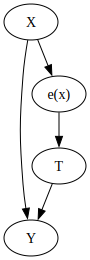

In [6]:
# Controlling for e(x) and T is the same
g = gr.Digraph()
g.edge("T", "Y")
g.edge("X", "Y")
g.edge("X", "e(x)")
g.edge("e(x)", "T")
g

Controlling for e(x) and T is the same

## Chapter 12: Doubly Robust Estimation

Doubly robust estimation = Reg + Propensity Score Estimation -> $E[Y|T=1] - E[Y|T=0] | X$

$$\hat{ATE} = \frac{1}{N} \sum_{i \in I} \left( \frac{T_i(Y_i - \hat{\mu}_i(X_i))}{\hat{P}(X_i)} + \hat{\mu}_1(X_i)    \right) - \frac{1}{N} \sum_{i \in I} \left( \frac{(1-T_i) (Y_i - \hat{\mu}_0(X_i))}{1- \hat{P}(X_i)}    + \hat{\mu}_0(X_i) \right)$$

$\hat{P}(x)$ is an estimation of the propensity score (logistic), $\hat{\mu}_1(x)$ is an estimation of $E[Y|X, T=1]$ (logistic), $\hat{\mu}_0(x)$ is an estimation of $E[Y|X, T=0]$ .

$$\hat{E}[Y_1] = \frac{1}{N} \sum  \left( \frac{T_i(Y_i - \hat{\mu}_i(X_i))}{\hat{P}(X_i)} + \hat{\mu}_1(X_i) \right)$$

In [12]:
data = pd.read_csv("./data/learning_mindset.csv")

categ = ["ethnicity", "gender", "school_urbanicity"]
cont = ["school_mindset", "school_achievement", "school_ethnic_minority", "school_poverty", "school_size"]

data_with_categ = pd.concat([
    data.drop(columns=categ), # dataset without the categorical features
    pd.get_dummies(data[categ], columns=categ, drop_first=False) # categorical features converted to dummies
], axis=1)


def doubly_robust(df, X, T, Y):
    ps = LogisticRegression(C=1e6, max_iter=1000).fit(df[X], df[T]).predict_proba(df[X])[:, 1]
    mu0 = LinearRegression().fit(df.query(f"{T}==0")[X], df.query(f"{T}==0")[Y]).predict(df[X])
    mu1 = LinearRegression().fit(df.query(f"{T}==1")[X], df.query(f"{T}==1")[Y]).predict(df[X])
    return (
        np.mean(df[T]*(df[Y] - mu1)/ps + mu1) -
        np.mean((1-df[T])*(df[Y] - mu0)/(1-ps) + mu0)
    )
T = 'intervention'
Y = 'achievement_score'
X = data_with_categ.columns.drop(['schoolid', T, Y])

print(doubly_robust(data_with_categ, X, T, Y))


from joblib import Parallel, delayed # for parallel processing

#Construct bootstrap confidence intervals
np.random.seed(88)
# run 1000 bootstrap samples
bootstrap_sample = 1000
ates = Parallel(n_jobs=4)(delayed(doubly_robust)(data_with_categ.sample(frac=1, replace=True), X, T, Y)
                          for _ in range(bootstrap_sample))
ates = np.array(ates)
print(f"ATE 95% CI:", (np.percentile(ates, 2.5), np.percentile(ates, 97.5)))


0.38814054583478264
ATE 95% CI: (np.float64(0.35365256104565984), np.float64(0.4197861573356079))


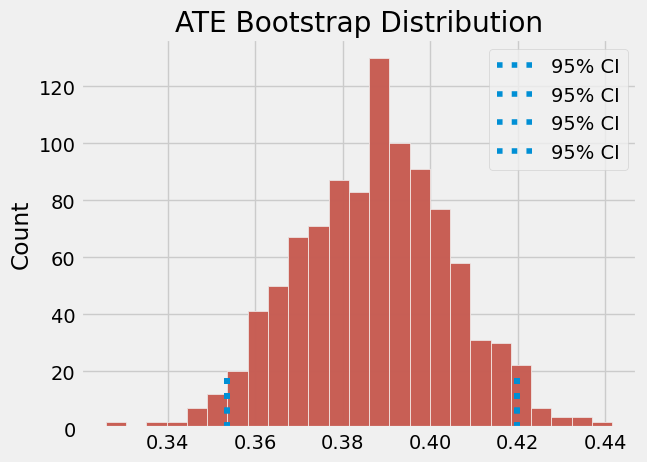

In [16]:
sns.histplot(ates, kde=False)
plt.vlines(np.percentile(ates, 2.5), 0, 20, linestyles="dotted")
plt.vlines(np.percentile(ates, 97.5), 0, 20, linestyles="dotted", label="95% CI")
plt.title("ATE Bootstrap Distribution")
plt.legend();
plt.show()

$$\hat{E}[Y_1] = \frac{1}{N} \sum \left(  \frac{T_i Y_i}{\hat{P}(X_i)} - \left( \frac{T_i - \hat{P}(X_i)}{\hat{P}(X_i)} \right) \hat{\mu}_1(X_i)  \right)$$

If $\hat{P}(X_i)$ correctly specified, then $E[] = 0$ so only first part matters

In [18]:
from sklearn.linear_model import LogisticRegression, LinearRegression

def doubly_robust_wrong_model(df, X, T, Y):
    np.random.seed(654)
    ps = LogisticRegression(C=1e6, max_iter=1000).fit(df[X], df[T]).predict_proba(df[X])[:, 1]
    
    # wrong mu(x) model
    mu0 = np.random.normal(0, 1, df.shape[0])
    mu1 = np.random.normal(0, 1, df.shape[0])
    return (
        np.mean(df[T]*(df[Y] - mu1)/ps + mu1) -
        np.mean((1-df[T])*(df[Y] - mu0)/(1-ps) + mu0)
    )
doubly_robust_wrong_model(data_with_categ, X, T, Y)

np.random.seed(88)
parallel_fn = delayed(doubly_robust_wrong_model)
wrong_mux = Parallel(n_jobs=4)(parallel_fn(data_with_categ.sample(frac=1, replace=True), X, T, Y)
                               for _ in range(bootstrap_sample))
wrong_mux = np.array(wrong_mux)

print(f"Original ATE 95% CI:", (np.percentile(ates, 2.5), np.percentile(ates, 97.5)))
print(f"Wrong Mu ATE 95% CI:", (np.percentile(wrong_mux, 2.5), np.percentile(wrong_mux, 97.5)))

Original ATE 95% CI: (np.float64(0.35365256104565984), np.float64(0.4197861573356079))
Wrong Mu ATE 95% CI: (np.float64(0.3386356664365645), np.float64(0.43303333234450814))
